<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and Config

In [2]:
import random
import pandas as pd

# Set random seed for reproducibility
random.seed(42)

In [3]:
from src.constants.constants import *
from src import ClassifierPipeline
from src.enums.SectionEnum import SectionEnum
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Load and Clean Dataset

## Load Hearings

In [4]:
# Load the ground-truth labelled sample set
labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

### Build the CSV ourselves

In [5]:
# from src import HearingLoader, HearingTagger

# # Initialize the HearingLoader with the corpus path
# loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
# tagger = HearingTagger()

# # Get only relevant hearings
# hearings = loader.load_all_committee_hearings()
# relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']

# # Randomly sample 100 hearings
# sampled_hearings = random.sample(relevant_hearings, 100)
# sampled_hearings = [tagger(h) for h in sampled_hearings]
# if sampled_hearings is None:
#     raise ValueError("tagger returned no valid hearings from random sample")

# # Build utterances dataframe from the sampled hearings using the new public method
# # This automatically sorts by state, bid, hid, uid and fills missing values
# utterances_df = tagger._build_utterances_dataframe(sampled_hearings)

# # save it to a csv
# utterances_df.to_csv('./utterances_sample.csv', index=False)

### Load the existing CSV

In [6]:
utterances_df = pd.read_csv('./utterances_sample.csv')

## Clean Loaded Hearings

In [7]:
# Fill missing values in labeled data for train/test splits
utterances_df[TEXT_COL] = utterances_df[TEXT_COL].fillna("")
labeled_utterances_df[TEXT_COL] = labeled_utterances_df[TEXT_COL].fillna("")

utterances_df[TOKEN_COL] = utterances_df[TOKEN_COL].fillna(UNKNOWN)
labeled_utterances_df[TOKEN_COL] = labeled_utterances_df[TOKEN_COL].fillna(UNKNOWN)

for col in NUM_COLS:
  if col in utterances_df.columns:
    utterances_df[col] = utterances_df[col].fillna(0)
  if col in labeled_utterances_df.columns:
    labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)

for col in CAT_COLS:
  if col in utterances_df.columns:
    utterances_df[col] = utterances_df[col].fillna(UNKNOWN)
  if col in labeled_utterances_df.columns:
    labeled_utterances_df[col] = labeled_utterances_df[col].fillna(UNKNOWN)

In [8]:
for col in utterances_df.columns:
    print(f"{col}\t{utterances_df[col].isna().sum()}")

state	0
bid	0
hid	0
uid	0
pid	0
speaker.position	0
speaker.position.value	30
can_file_motions	0
is_presenter	0
relative_position	0
token_count	0
sent_count	0
mentions_speaker	0
mentions_bill	0
speech_act_cues	0
section_cues	0
section	2619
text	0


In [9]:
nontoken_feature_cols = [
    c for c in utterances_df.columns
    if c not in labeled_utterances_df.columns
]
labeled_utterances_df[nontoken_feature_cols] = utterances_df[nontoken_feature_cols]


In [10]:
labeled_utterances_df.head()

,state,bid,hid,uid,pid,speaker.position,section,text,speaker.position.value,can_file_motions,is_presenter,relative_position,token_count,sent_count,mentions_speaker,mentions_bill,speech_act_cues,section_cues
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman BILL_AUTHOR you have three matters i...,8.0,True,False,0.000000,83,5,1,1,OTHER,OTHER
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you fo...,4.0,False,True,0.022727,373,18,0,1,OTHER,OTHER
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've ...,8.0,True,False,0.045455,24,3,0,0,OTHER,OTHER
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR,PRESENTATION,that's correct,4.0,False,True,0.068182,2,1,0,0,OTHER,OTHER
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR,PRESENTATION,and this is plan step two I guess or new step two,8.0,True,False,0.090909,13,1,0,0,OTHER,OTHER


In [11]:
labeled_utterances_df['section'].value_counts()

section
PUBLIC_COMMENTS          743
LEGISLATOR_DISCUSSION    740
VOTE                     248
EXPERT_TESTIMONY         221
CLOSING_REMARKS          191
PRESENTATION             138
OTHER_HEARING            102
INTRO                     84
OTHER_PROCEDURAL          84
OTHER_NONPROCEDURAL       68
Name: count, dtype: int64

# Evaluation

## Config

In [12]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=69,
)

In [13]:
# Create classifiers
lr_classifier = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=2000,
    random_state=42,
    solver='adam'
)

# Create parsers with different classifiers and masking configurations
parser_lr_mask = ClassifierPipeline(
    base_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs'),
    masking=True,
    smoothing=False
)

parser_lr_nomask = ClassifierPipeline(
    base_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs'),
    masking=False,
    smoothing=False
)

parser_mlp_mask = ClassifierPipeline(
    base_estimator=MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42, solver='adam'),
    masking=True,
    smoothing=False
)

parser_mlp_nomask = ClassifierPipeline(
    base_estimator=MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42, solver='adam'),
    masking=False,
    smoothing=False
)

In [14]:
# Create a combined group identifier for bid+hid
labeled_utterances_df['hearing_group'] = labeled_utterances_df['bid'].astype(str) + '_' + labeled_utterances_df['hid'].astype(str)

train_idx, test_idx = next(
    splitter.split(
        labeled_utterances_df, 
        labeled_utterances_df['section'], 
        groups=labeled_utterances_df['hearing_group']
    )
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

# Sort by hearing_group and uid to match the order that predict() returns
train_df = train_df.sort_values(by=['hearing_group', 'uid']).reset_index(drop=True)
test_df = test_df.sort_values(by=['hearing_group', 'uid']).reset_index(drop=True)

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train hearings:', train_df['hearing_group'].nunique())
print('Test hearings:', test_df['hearing_group'].nunique())

Train rows: 2010
Test rows: 609
Train hearings: 75
Test hearings: 25


In [15]:
# Prepare train and test data
X_train = train_df[FEATURE_COLS + ["uid", "hearing_group"]]
y_train = train_df['section']

X_test = test_df[FEATURE_COLS + ["uid", "hearing_group"]]
y_test = test_df['section']

## Train models

In [16]:
for col in X_train.columns:
    print(f"{col}\t{X_train[col].isna().sum()}")

speaker.position	0
text	0
section_cues	0
speech_act_cues	0
relative_position	0
sent_count	0
token_count	0
mentions_speaker	0
mentions_bill	0
uid	0
hearing_group	0


In [17]:
# Train all four models
print("Training Logistic Regression model (masking=True)...")
parser_lr_mask.fit(X_train, y_train)

print("Training Logistic Regression model (masking=False)...")
parser_lr_nomask.fit(X_train, y_train)

print("Training MLP classifier model (masking=True)...")
parser_mlp_mask.fit(X_train, y_train)

print("Training MLP classifier model (masking=False)...")
parser_mlp_nomask.fit(X_train, y_train)

Training Logistic Regression model (masking=True)...
Training Logistic Regression model (masking=False)...
Training MLP classifier model (masking=True)...
Training MLP classifier model (masking=False)...


## Evaluation Results

In [18]:
import numpy as np
from sklearn.metrics import classification_report

label_order = [s.value for s in list(SectionEnum)]

In [19]:
# Evaluate all four models
print("=" * 80)
print("LOGISTIC REGRESSION MODEL (masking=True)")
print("=" * 80)

pred_lr_mask = parser_lr_mask.predict(X_test)

print(classification_report(
    y_test,
    pred_lr_mask,
    labels=label_order,
    digits=3,
))

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION MODEL (masking=False)")
print("=" * 80)

pred_lr_nomask = parser_lr_nomask.predict(X_test)

print(classification_report(
    y_test,
    pred_lr_nomask,
    labels=label_order,
    digits=3,
))

LOGISTIC REGRESSION MODEL (masking=True)
                       precision    recall  f1-score   support

                INTRO      0.792     0.704     0.745        27
         PRESENTATION      0.690     0.714     0.702        28
LEGISLATOR_DISCUSSION      0.921     0.671     0.777       207
     EXPERT_TESTIMONY      0.568     0.700     0.627        60
      PUBLIC_COMMENTS      0.868     0.861     0.864       137
      CLOSING_REMARKS      0.767     0.717     0.742        46
                 VOTE      0.731     0.760     0.745        50
        OTHER_HEARING      0.206     0.241     0.222        29
     OTHER_PROCEDURAL      0.175     0.538     0.264        13
  OTHER_NONPROCEDURAL      0.154     0.333     0.211        12

             accuracy                          0.701       609
            macro avg      0.587     0.624     0.590       609
         weighted avg      0.765     0.701     0.723       609


LOGISTIC REGRESSION MODEL (masking=False)
                       precisio

In [20]:
# Evaluate MLP models
print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL (masking=True)")
print("=" * 80)

pred_mlp_mask = parser_mlp_mask.predict(X_test)

print(classification_report(
    y_test,
    pred_mlp_mask,
    labels=label_order,
    digits=3,
))

print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL (masking=False)")
print("=" * 80)

pred_mlp_nomask = parser_mlp_nomask.predict(X_test)

print(classification_report(
    y_test,
    pred_mlp_nomask,
    labels=label_order,
    digits=3,
))


MLP CLASSIFIER MODEL (masking=True)
                       precision    recall  f1-score   support

                INTRO      0.722     0.481     0.578        27
         PRESENTATION      0.536     0.536     0.536        28
LEGISLATOR_DISCUSSION      0.764     0.749     0.756       207
     EXPERT_TESTIMONY      0.618     0.567     0.591        60
      PUBLIC_COMMENTS      0.821     0.905     0.861       137
      CLOSING_REMARKS      0.676     0.543     0.602        46
                 VOTE      0.655     0.760     0.704        50
        OTHER_HEARING      0.238     0.172     0.200        29
     OTHER_PROCEDURAL      0.200     0.385     0.263        13
  OTHER_NONPROCEDURAL      0.231     0.250     0.240        12

             accuracy                          0.685       609
            macro avg      0.546     0.535     0.533       609
         weighted avg      0.687     0.685     0.682       609


MLP CLASSIFIER MODEL (masking=False)
                       precision    reca

## Confusion Matrix

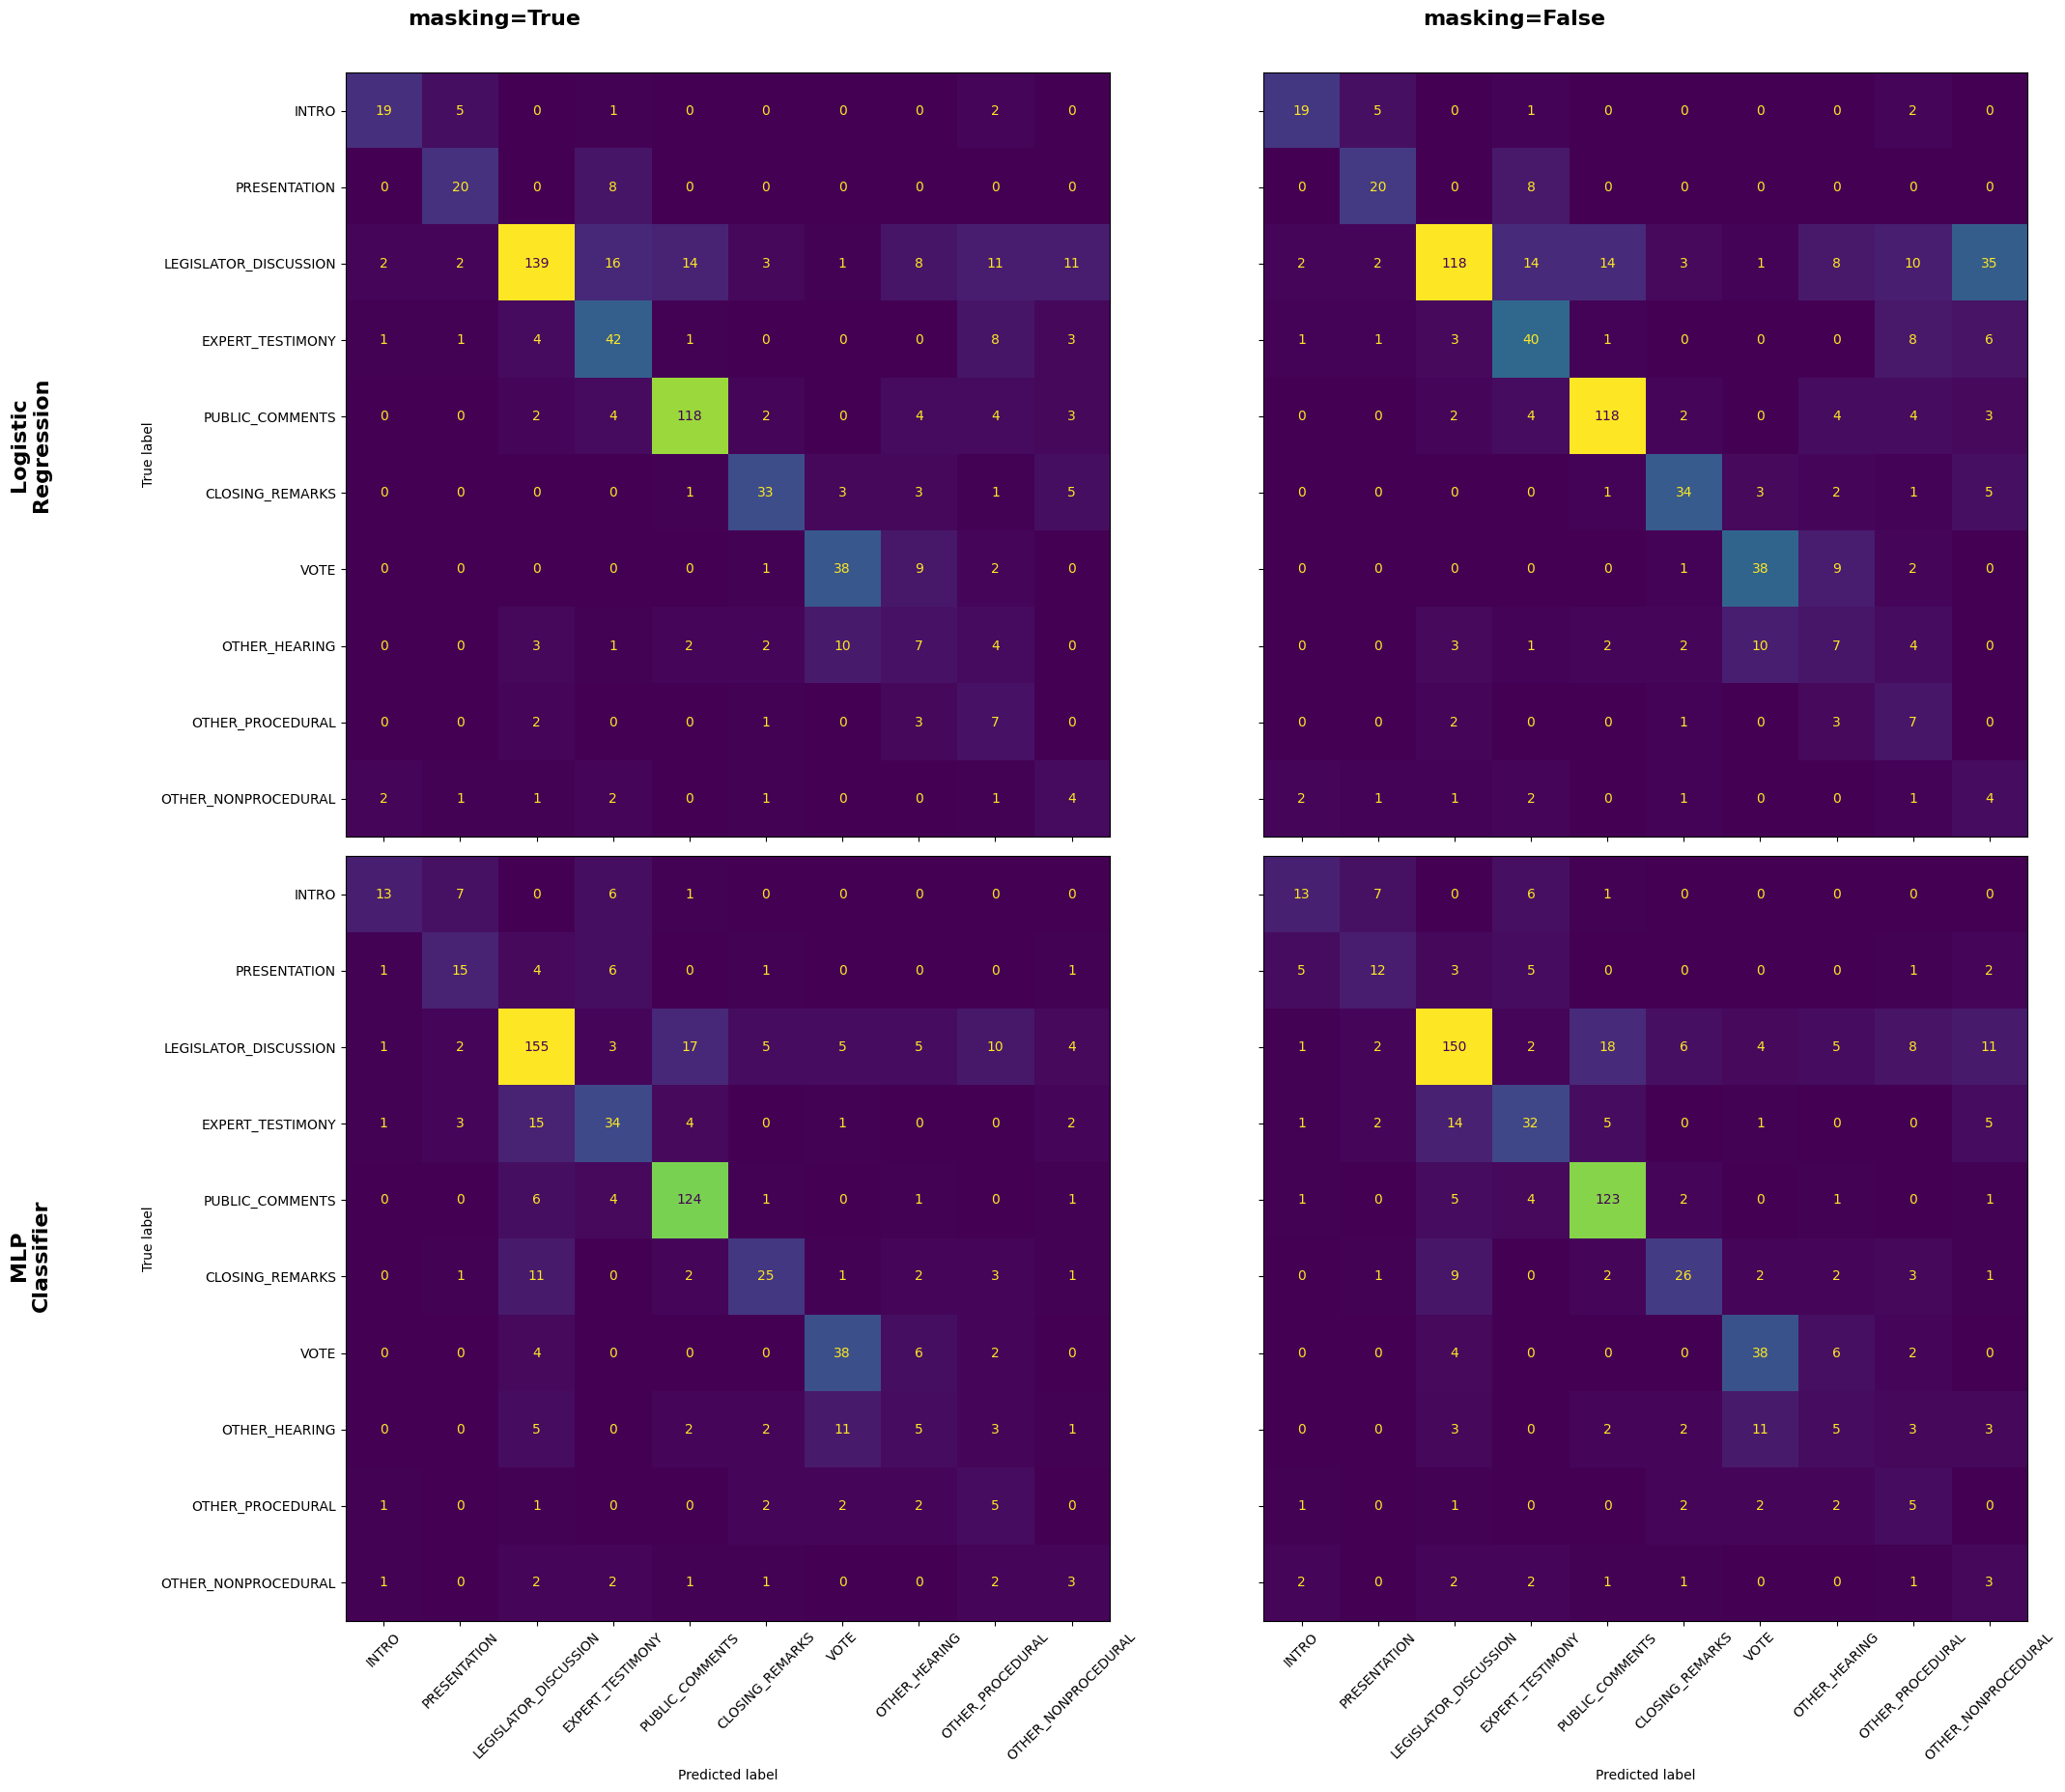

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Filter to only labels present in test set
labels = [label for label in label_order if label in y_test.unique()]

# Create 2x2 grid of confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(24, 20))

# Logistic Regression with masking=True
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr_mask,
    labels=labels,
    xticks_rotation=45,
    ax=axes[0, 0],
    colorbar=False,
)
axes[0, 0].set_xlabel('')  # Remove x-axis label
axes[0, 0].set_xticklabels([])  # Remove x-axis tick labels

# Logistic Regression with masking=False
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr_nomask,
    labels=labels,
    xticks_rotation=45,
    ax=axes[0, 1],
    colorbar=False,
)
axes[0, 1].set_xlabel('')  # Remove x-axis label
axes[0, 1].set_xticklabels([])  # Remove x-axis tick labels
axes[0, 1].set_ylabel('')  # Remove y-axis label
axes[0, 1].set_yticklabels([])  # Remove y-axis tick labels

# MLP with masking=True
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mlp_mask,
    labels=labels,
    xticks_rotation=45,
    ax=axes[1, 0],
    colorbar=False,
)

# MLP with masking=False
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mlp_nomask,
    labels=labels,
    xticks_rotation=45,
    ax=axes[1, 1],
    colorbar=False,
)
axes[1, 1].set_ylabel('')  # Remove y-axis label
axes[1, 1].set_yticklabels([])  # Remove y-axis tick labels

# Add column titles for masking
fig.text(0.28, 0.92, 'masking=True', ha='center', va='center', fontsize=16, fontweight='bold')
fig.text(0.72, 0.92, 'masking=False', ha='center', va='center', fontsize=16, fontweight='bold')

# Add row titles for model types
fig.text(0.08, 0.70, 'Logistic\nRegression', ha='center', va='center', fontsize=16, fontweight='bold', rotation=90)
fig.text(0.08, 0.28, 'MLP\nClassifier', ha='center', va='center', fontsize=16, fontweight='bold', rotation=90)

plt.tight_layout(rect=[0.1, 0, 1, 0.9])
plt.show()

In [22]:
# Group test data by hearing for individual hearing predictions
test_hearings_grouped = {}
for hearing_group in test_df['hearing_group'].unique():
    hearing_data = test_df[test_df['hearing_group'] == hearing_group].sort_values('uid')
    bid = hearing_data['bid'].iloc[0]
    hid = hearing_data['hid'].iloc[0]
    test_hearings_grouped[hearing_group] = {
        'bid': bid,
        'hid': hid,
        'data': hearing_data[FEATURE_COLS + ['uid', 'hearing_group']]
    }

In [23]:
sample_hearing_id, sample_hearing_data = list(test_hearings_grouped.items())[0]

# Use the new ClassifierPipeline predict interface
labels_lr_mask = parser_lr_mask.predict(sample_hearing_data['data'])

print("Logistic Regression (masking=True) predictions:")
print(labels_lr_mask)

print("\n" + "=" * 80 + "\n")

# Use the new ClassifierPipeline predict interface
labels_mlp_mask = parser_mlp_mask.predict(sample_hearing_data['data'])

print("MLP Classifier (masking=True) predictions:")
print(labels_mlp_mask)

Logistic Regression (masking=True) predictions:
['PRESENTATION' 'EXPERT_TESTIMONY' 'EXPERT_TESTIMONY' 'OTHER_PROCEDURAL'
 'EXPERT_TESTIMONY' 'PUBLIC_COMMENTS' 'CLOSING_REMARKS' 'OTHER_PROCEDURAL'
 'LEGISLATOR_DISCUSSION' 'VOTE' 'OTHER_HEARING' 'CLOSING_REMARKS'
 'OTHER_HEARING' 'OTHER_HEARING' 'CLOSING_REMARKS']


MLP Classifier (masking=True) predictions:
['PRESENTATION' 'EXPERT_TESTIMONY' 'PRESENTATION' 'EXPERT_TESTIMONY'
 'EXPERT_TESTIMONY' 'PUBLIC_COMMENTS' 'PRESENTATION' 'CLOSING_REMARKS'
 'LEGISLATOR_DISCUSSION' 'VOTE' 'OTHER_HEARING' 'OTHER_PROCEDURAL'
 'OTHER_HEARING' 'OTHER_HEARING' 'OTHER_NONPROCEDURAL']


In [24]:
# Special hearing lookup using utterances_df
special_hearing_df = labeled_utterances_df[labeled_utterances_df['bid'] == 'CA_201720180AB2721']
if len(special_hearing_df) > 0:
    print(f"Found special hearing: {special_hearing_df['bid'].iloc[0]} (hid: {special_hearing_df['hid'].iloc[0]})")
else:
    print("Special hearing CA_201720180AB2721 not found in dataset")

Found special hearing: CA_201720180AB2721 (hid: 254896)


Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

# Sanity Checks

In [25]:
def pprint_hearing_labels(bid, hid, hearing_df, labeled_utterances_df, parser, model_name=""):
  """Print formatted transcript with predicted section labels.
  
  Args:
      bid: Bill ID
      hid: Hearing ID
      hearing_df: DataFrame with utterance features and 'hearing_group' column
      labeled_utterances_df: DataFrame with ground truth labels and text
      parser: ClassifierPipeline instance with trained model
      model_name: Name of the model for display purposes
  """
  # Predict using the new interface - just pass the DataFrame with hearing_group
  pred_labels = parser.predict(hearing_df)
  
  # Filter labeled_utterances_df for this specific hearing
  hearing_labels = labeled_utterances_df[
    (labeled_utterances_df['bid'] == bid) & 
    (labeled_utterances_df['hid'] == hid)
  ].sort_values('uid')
  
  true_labels = hearing_labels['section'].values

  print()
  if model_name:
    print(f"Model: {model_name}")
  print(f"Bill:\t\t{bid}")
  print(f"Hearing ID:\t{hid}")
  print()
  print("Transcript (predictions vs ground truth):")
  print()
  
  for i, row in hearing_labels.iterrows():
    print(f'Predicted label:\t[{pred_labels[i] if i < len(pred_labels) else "UNKNOWN"}]')
    print(f'True label:\t\t[{row["section"]}]')
    print(f'Speaker position:\t{row["speaker.position"]}')
    print(f'Text:\t\t\t{row["text"][:100]}{"..." if len(row["text"]) > 100 else ""}')
    print()
  print()

In [26]:
print("=" * 80)
print("LOGISTIC REGRESSION MODEL (masking=True)")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing_data['bid'],
    sample_hearing_data['hid'],
    sample_hearing_data['data'],
    labeled_utterances_df, 
    parser_lr_mask, 
    "Logistic Regression (masking=True)")

print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL (masking=True)")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing_data['bid'],
    sample_hearing_data['hid'],
    sample_hearing_data['data'],
    labeled_utterances_df, 
    parser_mlp_mask, 
    "MLP Classifier (masking=True)")

LOGISTIC REGRESSION MODEL (masking=True)

Model: Logistic Regression (masking=True)
Bill:		CA_201720180AB1013
Hearing ID:	254930

Transcript (predictions vs ground truth):

Predicted label:	[UNKNOWN]
True label:		[PRESENTATION]
Speaker position:	BILL_AUTHOR
Text:			this is ORG bill 1013 with respect to allowing voters who might have disabilities to be able to vote...

Predicted label:	[UNKNOWN]
True label:		[EXPERT_TESTIMONY]
Speaker position:	PRESIDING_CHAIR
Text:			thank you witnesses in support

Predicted label:	[UNKNOWN]
True label:		[EXPERT_TESTIMONY]
Speaker position:	EXPERT
Text:			would you like to sit at the table or want to sit up here by the

Predicted label:	[UNKNOWN]
True label:		[EXPERT_TESTIMONY]
Speaker position:	PRESIDING_CHAIR
Text:			good afternoon

Predicted label:	[UNKNOWN]
True label:		[EXPERT_TESTIMONY]
Speaker position:	EXPERT
Text:			good afternoon mr chair and members NONLEGISLATOR representing ORG I am fortunate I live in GPE a vo...

Predicted label:	[UNKNOW